**Working Procedure/ Steps:**

Wear the required Personal Protective Equipment (PPE) for the job.

Observe and follow appropriate occupational health and safety (OHS) requirements during the demonstration.

Check Electricity, Peripheral device & Internet Connections to your Computer.

Start the Computer.

Check for software errors and troubleshoot problems.

Collect the required resources (dataset and materials) from the assessor as per the job requirement.

Create a Sentiment Analysis System using Deep Learning.

Set up the Python environment required to complete the project.

Load and inspect the dataset.

Prepare the data (cleaning, noise removal, and data annotation).

Extract relevant features and transform the data (e.g., tokenization, embedding, normalization).

Split the dataset into training, validation, and testing sets. (added – mandatory for DL)

Design the deep learning model architecture.

Compile and train the model.

Evaluate the model performance using appropriate metrics.

Visualize model performance (loss, accuracy, or error trends).

Detect overfitting and underfitting using training and validation results.

Save and deploy the final trained model.

Submit the final output to the competency assessor.

Shut down the computer and clean your workplace.

Clean tools, equipment, materials, and work area.

🔹 Step 1: Environment Setup

In [1]:
# Install required libraries (run once)
# pip install pandas numpy matplotlib scikit-learn tensorflow

🔹 Step 2: Import Libraries

In [2]:
# ============================================
# 🔹 Step 0: Imports
# ============================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

2026-03-02 23:54:31.177518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772495671.405764      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772495671.468719      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772495671.981556      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772495671.981605      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772495671.981608      24 computation_placer.cc:177] computation placer alr

🔹 Step 3: Load & Inspect Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ronimahabub21/job-3-resource-sentiment-csv/Job_3_Resource_sentiment.csv")
print(df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [4]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [6]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)

In [7]:
df.columns

Index(['2401', 'Borderlands', 'sentiment', 'text'], dtype='object')

In [8]:
df = df[['text', 'sentiment']]

In [9]:
df.sample(5)

,text,sentiment
55758,Call of Duty: WARZONE is definitely on the top...,Positive
51527,Red dead redemption 2 is awesome because I put...,Positive
69325,I. support this:),Positive
68697,and So shit went sideways with . . twitch.tv/...,Neutral
41391,Great final shots from @Ramsey111uk. [UNK],Irrelevant


In [10]:
df.shape

(74681, 2)

In [11]:
df.isnull().sum()

text         686
sentiment      0
dtype: int64

In [12]:
print(df['sentiment'].value_counts())

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


🔹 Step 4: Data Cleaning

In [13]:
# Drop missing values
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

In [15]:
# Convert text to string
df['text'] = df['text'].astype(str)

In [16]:
df['text']

0        I am coming to the borders and I will kill you...
1        im getting on borderlands and i will kill you ...
2        im coming on borderlands and i will murder you...
3        im getting on borderlands 2 and i will murder ...
4        im getting into borderlands and i can murder y...
                               ...                        
74676    Just realized that the Windows partition of my...
74677    Just realized that my Mac window partition is ...
74678    Just realized the windows partition of my Mac ...
74679    Just realized between the windows partition of...
74680    Just like the windows partition of my Mac is l...
Name: text, Length: 73995, dtype: object

In [17]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

In [18]:
df['text']

0        i am coming to the borders and i will kill you...
1        im getting on borderlands and i will kill you all
2        im coming on borderlands and i will murder you...
3        im getting on borderlands  and i will murder y...
4        im getting into borderlands and i can murder y...
                               ...                        
74676    just realized that the windows partition of my...
74677    just realized that my mac window partition is ...
74678    just realized the windows partition of my mac ...
74679    just realized between the windows partition of...
74680    just like the windows partition of my mac is l...
Name: text, Length: 73995, dtype: object

🔹 Step 5: Encode Target Labels

In [19]:
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


🔹 Step 6: Text Tokenization & Padding

In [20]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values

In [21]:
y

array([3, 3, 3, ..., 3, 3, 3])

🔹 Step 7: Train / Validation / Test Split (MANDATORY)

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Train: (51796, 100)
Validation: (11099, 100)
Test: (11100, 100)


Handle Bias (Class Weight)

In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4368619618286729), 1: np.float64(0.8274121405750798), 2: np.float64(1.0215367623856106), 3: np.float64(0.8956287176649605)}


🔹 Step 8: Build Deep Learning Model (LSTM)

In [24]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

I0000 00:00:1772495696.113664      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772495696.116303      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

🔹 Step 9: Compile Model

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

🔹 Step 10: Train Model

In [26]:
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20


I0000 00:00:1772495700.425991      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


1619/1619 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5308 - loss: 1.0930 - val_accuracy: 0.7547 - val_loss: 0.6448
Epoch 2/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8306 - loss: 0.4674 - val_accuracy: 0.8240 - val_loss: 0.4814
Epoch 3/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8891 - loss: 0.3053 - val_accuracy: 0.8364 - val_loss: 0.4520
Epoch 4/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9156 - loss: 0.2290 - val_accuracy: 0.8537 - val_loss: 0.4346
Epoch 5/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9255 - loss: 0.1954 - val_accuracy: 0.8489 - val_loss: 0.4701
Epoch 6/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9354 - loss: 0.1682 - val_accuracy: 0.8467 - val_loss: 0.5398
Epoch 7/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9400 - loss: 0.1545 - val_accuracy: 0.8644 - val_loss: 0.4762


🔹 Step 11: Visualize Performance

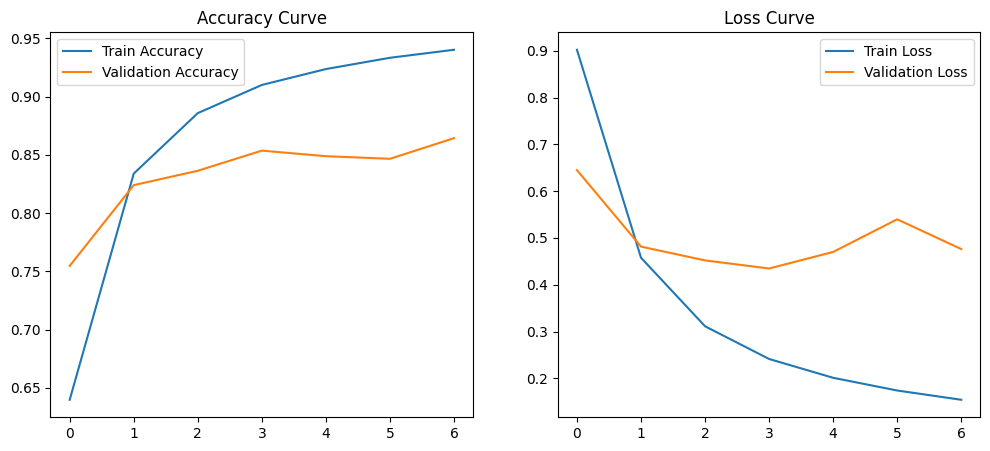

In [27]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

🔹 Step 12: Detect Overfitting / Underfitting

In [28]:
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("⚠️ Possible Overfitting detected")
else:
    print("✅ Model is generalizing well")

⚠️ Possible Overfitting detected


🔹 Step 13: Model Evaluation

In [29]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.8572072072072072
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1932
           1       0.87      0.89      0.88      3354
           2       0.85      0.83      0.84      2716
           3       0.85      0.87      0.86      3098

    accuracy                           0.86     11100
   macro avg       0.86      0.85      0.85     11100
weighted avg       0.86      0.86      0.86     11100



🔹 Step 14: Save Model

In [30]:
model.save("sentiment_analysis_model.keras")
print("✅ Model saved successfully")

✅ Model saved successfully


🔹 Step 15: Test with New Text

In [31]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100, padding='post')
    probs = model.predict(pad)[0]
    return encoder.classes_[probs.argmax()], probs

texts = [
    "I love this game so much",
    "This game is terrible",
    "I have no opinion",
    "What is this even about?"
]

for t in texts:
    pred, prob = predict_sentiment(t)
    print(t, "->", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
I love this game so much -> Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
This game is terrible -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
I have no opinion -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
What is this even about? -> Negative
